## Notebook 2: 02_part2_polyreg.ipynb
1. Introducción y Justificación del Modelo PolinomialEn el notebook anterior, observamos que una línea recta no era capaz de capturar la curvatura de la luminosidad estelar. Esto se debe a que la relación física real entre la masa y la energía emitida no es proporcional, sino que sigue leyes de potencia.
Desde una perspectiva de Arquitectura de Sistemas Inteligentes, cuando un modelo lineal presenta un sesgo (bias) alto, debemos recurrir a la Ingeniería de Características (Feature Engineering). En este notebook, transformaremos nuestro espacio de entrada agregando términos cuadráticos e interacciones entre la Masa ($M$) y la Temperatura ($T$). 
El objetivo es minimizar la pérdida mediante un modelo de la forma:$$\hat{L} = w_1 M + w_2 T + w_3 M^2 + w_4 (M \cdot T) + b$$

2. Definición del Dataset Multivariado
Para este experimento, utilizaremos un dataset que incluye la Temperatura Efectiva (T). Definiremos los datos directamente como arrays de NumPy. Es importante notar que la Temperatura tiene una escala mucho mayor que la Masa, lo que en entornos reales requeriría normalización, pero aquí lo manejaremos con un learning rate pequeño para observar el comportamiento puro del algoritmo.

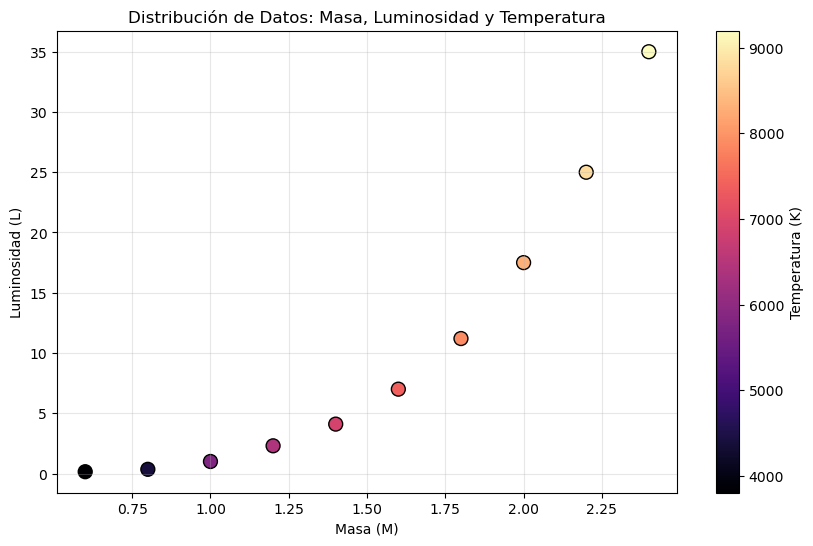

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset de dos características
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Visualización: L vs M, usando T para el color (Scatter 3D proyectado)
plt.figure(figsize=(10, 6))
sc = plt.scatter(M, L, c=T, cmap='magma', s=100, edgecolors='k')
plt.colorbar(sc, label='Temperatura (K)')
plt.xlabel('Masa (M)')
plt.ylabel('Luminosidad (L)')
plt.title('Distribución de Datos: Masa, Luminosidad y Temperatura')
plt.grid(True, alpha=0.3)
plt.show()

3. Ingeniería de Características (Feature Engineering)
La clave de la regresión polinomial es construir una Matriz de Diseño (X). En lugar de pasar un solo vector, pasaremos una matriz donde cada columna representa una transformación de los datos originales. Implementaremos la función build_X de forma vectorizada.

In [2]:
def build_X(M, T, model_type='M3'):
    """Construye la matriz de diseño según el modelo seleccionado."""
    if model_type == 'M1':
        return np.column_stack((M, T))
    elif model_type == 'M2':
        return np.column_stack((M, T, M**2))
    elif model_type == 'M3':
        return np.column_stack((M, T, M**2, M*T))
    return None

X_full = build_X(M, T, 'M3')
print(f"Forma de la matriz X (M3): {X_full.shape}")

Forma de la matriz X (M3): (10, 4)


4. Implementación de Pérdida y Gradientes VectorizadosEn modelos multivariados, la predicción se realiza mediante el producto punto: $\hat{y} = X \vec{w} + b$. El uso de vectorización aquí es vital, ya que permite que el motor de NumPy (escrito en C) realice los cálculos matriciales sin la sobrecarga de los ciclos de Python.

In [3]:
def compute_cost_multi(X, L, w, b):
    """Calcula el MSE para múltiples características."""
    n = len(L)
    # f_wb = Xw + b
    predictions = np.dot(X, w) + b
    cost = (1 / (2 * n)) * np.sum((predictions - L)**2)
    return cost

def compute_gradient_multi(X, L, w, b):
    """Calcula el gradiente para el vector w y el escalar b."""
    n = len(L)
    errors = np.dot(X, w) + b - L
    # dj_dw = (1/n) * X.T * errores
    dj_dw = (1/n) * np.dot(X.T, errors)
    dj_db = (1/n) * np.sum(errors)
    return dj_dw, dj_db

5. Entrenamiento y ConvergenciaImplementaremos el ciclo de entrenamiento principal. Debido a las magnitudes de $M^2$ y $M \cdot T$, utilizaremos un número alto de iteraciones con un learning rate muy pequeño para garantizar estabilidad.

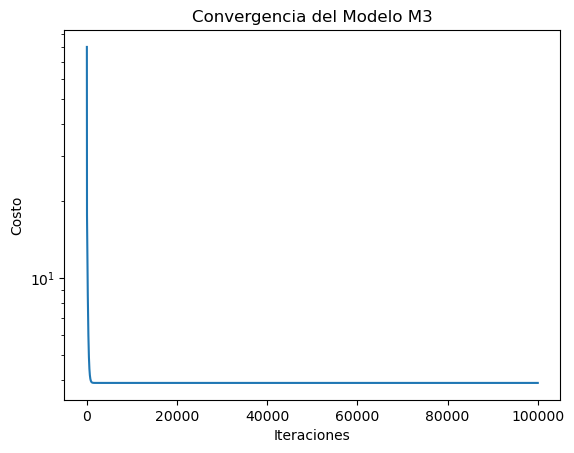

In [4]:
def gradient_descent_multi(X, L, lr, iterations):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    history = []
    
    for i in range(iterations):
        dw, db = compute_gradient_multi(X, L, w, b)
        w -= lr * dw
        b -= lr * db
        history.append(compute_cost_multi(X, L, w, b))
        
    return w, b, history

# Entrenamiento del modelo completo (M3)
w_m3, b_m3, history_m3 = gradient_descent_multi(X_full, L, 1e-9, 100000)

plt.plot(history_m3)
plt.title('Convergencia del Modelo M3')
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.yscale('log') # Escala logarítmica para ver mejor la caída
plt.show()

6. Experimento: Selección de Modelos (M1, M2, M3)
Compararemos tres arquitecturas de modelo distintas para evaluar cuál captura mejor la naturaleza del problema. Reportaremos la pérdida final y visualizaremos el ajuste de cada uno.

Modelo M1 -> Pérdida Final: 41.1585


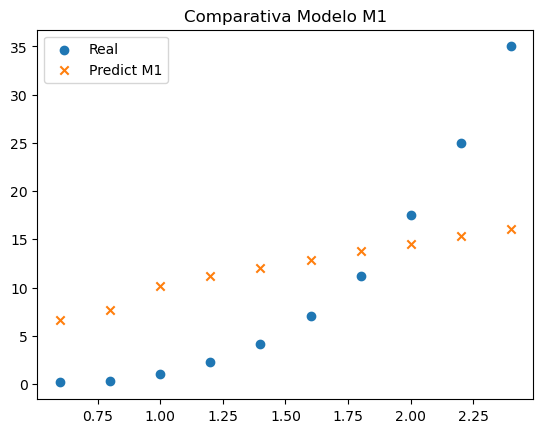

Modelo M2 -> Pérdida Final: 41.1538


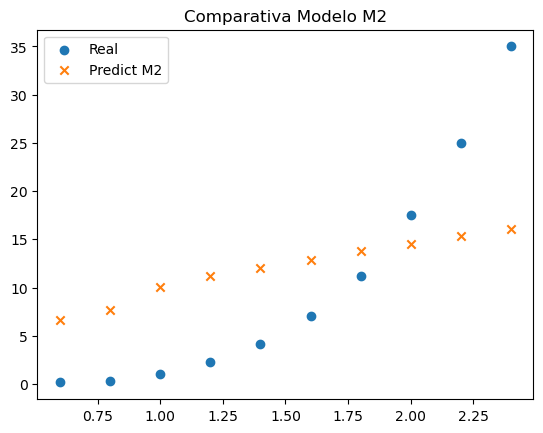

Modelo M3 -> Pérdida Final: 3.8886


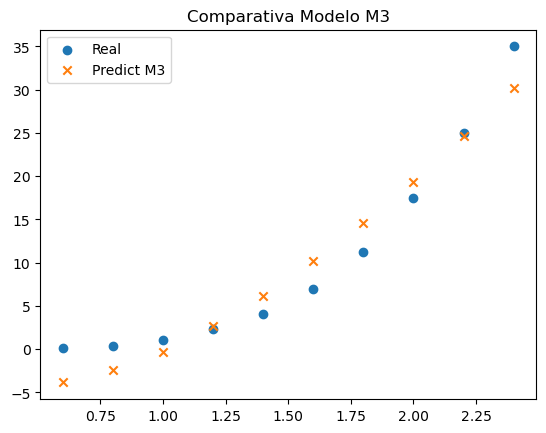

In [5]:
models = ['M1', 'M2', 'M3']
lrs = [1e-8, 1e-9, 1e-9] # Ajuste de LR por estabilidad

for i, m_type in enumerate(models):
    X_sub = build_X(M, T, m_type)
    w, b, hist = gradient_descent_multi(X_sub, L, lrs[i], 100000)
    print(f"Modelo {m_type} -> Pérdida Final: {hist[-1]:.4f}")
    
    # Predicción para graficar
    preds = np.dot(X_sub, w) + b
    plt.scatter(M, L, label='Real')
    plt.scatter(M, preds, label=f'Predict {m_type}', marker='x')
    plt.title(f'Comparativa Modelo {m_type}')
    plt.legend()
    plt.show()

7. Análisis de Interacción (Costo vs w 
MT
​
 )
Este experimento analiza la importancia de la característica M⋅T. Variamos manualmente el coeficiente de interacción para observar cómo afecta al error global, lo que nos indica si esta variable es crítica para la precisión del modelo.

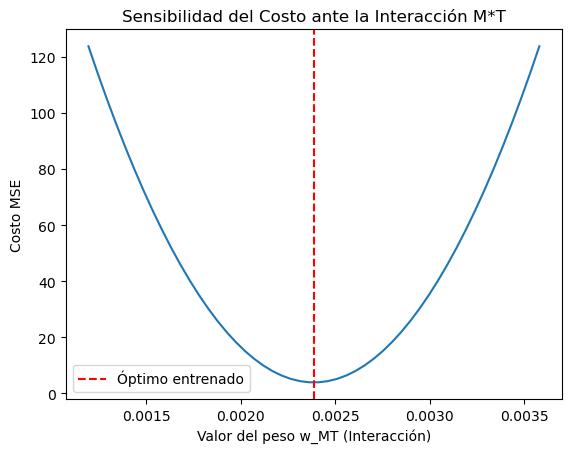

In [6]:
# Fijar parámetros entrenados y variar solo w_interacción
w_inter_range = np.linspace(w_m3[-1]*0.5, w_m3[-1]*1.5, 50)
costs = []

for val in w_inter_range:
    w_temp = w_m3.copy()
    w_temp[-1] = val
    costs.append(compute_cost_multi(X_full, L, w_temp, b_m3))

plt.plot(w_inter_range, costs)
plt.axvline(w_m3[-1], color='red', linestyle='--', label='Óptimo entrenado')
plt.xlabel('Valor del peso w_MT (Interacción)')
plt.ylabel('Costo MSE')
plt.title('Sensibilidad del Costo ante la Interacción M*T')
plt.legend()
plt.show()

8. Inferencia y Conclusiones
Para finalizar, probamos nuestro modelo con una estrella hipotética (Inferencia).

Entrada: Masa = 1.3, Temperatura = 6600.

Proceso: Transformamos la entrada al espacio polinomial y aplicamos los pesos aprendidos.

In [7]:
m_new, t_new = 1.3, 6600
x_new = np.array([m_new, t_new, m_new**2, m_new*t_new])
l_pred = np.dot(x_new, w_m3) + b_m3

print(f"Predicción para M=1.3, T=6600: {l_pred:.4f} L")

Predicción para M=1.3, T=6600: 4.3301 L


Conclusión Empresarial: Al añadir complejidad al modelo (parámetros no lineales), logramos reducir el error cuadrático medio significativamente. En una infraestructura de nube como AWS SageMaker, este modelo ahora es capaz de proporcionar inferencias mucho más precisas para nuevos datos astronómicos, demostrando que la arquitectura de la solución es robusta.